In [1]:
import torch
print(torch.cuda.is_available())  # True, если CUDA доступна
print(torch.version.cuda)         # версия CUDA, используемая PyTorch

True
12.8


In [30]:
from datasets import load_dataset

dataset = load_dataset("BW/RU_SPELLCHECK_DEVICE", split="train")
df = dataset.to_pandas().dropna()

sources = df["typed"].tolist()
corrections = df["original"].tolist()

print("Successfully loaded dataset BW/RU_SPELLCHECK_DEVICE from Hugging Face.")
print(f"Number of rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Number of sources: {len(sources)}")
print(f"Number of corrections: {len(corrections)}")

print("\nFirst 5 sources:")
for s in sources[:5]:
    print(s)
print("\nFirst 5 corrections:")
for c in corrections[:5]:
    print(c)

Successfully loaded dataset BW/RU_SPELLCHECK_DEVICE from Hugging Face.
Number of rows: 579
Columns: ['id', 'created_at', 'player_id', 'device_type', 'original', 'typed']
Number of sources: 579
Number of corrections: 579

First 5 sources:
Златые времена! О кроткин законы! народу своему прощант миллионы;
Воротился старик ко старухе ,У старухи новое корвто.
- Вы, кажется, решительно предпочитпетн камеристок.
Сказкв о попе и о работнике его Балде автлр Александр Сергеевич Пушкин (1799-1837) СКАЗКА О ПОПЕ И О РАБОТНИКЕ ЕГО БПЛДН Жил был поп, Толоконныц лоб 
Герианн трепетал, как тигр, лжидпч назначенного вреиент.

First 5 corrections:
Златые времена! О кроткие законы! Народу своему прощает миллионы;
Воротился старик ко старухе, У старухи новое корыто.
— Вы, кажется, решительно предпочитаете камеристок.
Сказка о попе и о работнике его Балде автор Александр Сергеевич Пушкин (1799—1837) СКАЗКА О ПОПЕ И О РАБОТНИКЕ ЕГО БАЛДЕ Жил-был поп, Толоконный лоб.
Германн трепетал, как тигр, ожидая назнач

In [4]:
from datasets import concatenate_datasets, load_dataset

# datasets>=4 не поддерживает spellcheck_benchmark.py — грузим JSON напрямую
HF_REPO = "ai-forever/spellcheck_benchmark"
MD_BASE = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main/data/MultidomainGold"

multidomain_gold = load_dataset(
    "json",
    data_files={
        "train": f"{MD_BASE}/train.json",
        "test": f"{MD_BASE}/test.json",
    },
)

multidomain_all = concatenate_datasets(
    [multidomain_gold["train"], multidomain_gold["test"]]
)
md_df = multidomain_all.to_pandas()

md_sources = md_df["source"].tolist()
md_corrections = md_df["correction"].tolist()

print(f"Loaded {HF_REPO} — subset MultidomainGold only.")
print(f"Train: {len(multidomain_gold['train'])} rows")
print(f"Test: {len(multidomain_gold['test'])} rows")
print(f"Total: {len(md_df)} rows")
print(f"Domains: {sorted(md_df['domain'].unique())}")

print("\nFirst 3 examples:")
for i in range(3):
    print(f"[{md_df.iloc[i]['domain']}]")
    print(f"  source: {md_sources[i][:120]}...")
    print(f"  correction: {md_corrections[i][:120]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Loaded ai-forever/spellcheck_benchmark — subset MultidomainGold only.
Train: 3571 rows
Test: 4107 rows
Total: 7678 rows
Domains: ['literature', 'news', 'reviews', 'social_media', 'strategic_documents', 'subtitles', 'web']

First 3 examples:
[web]
  source: Купить Nutrilon-1 гипоалергенный сухая смесь детская 400,0 в Москве можно в удобной для вас аптеке, сделав заказ на Apte...
  correction: Купить Nutrilon-1 гипоаллергенный сухая смесь детская 400,0 в Москве можно в удобной для вас аптеке, сделав заказ на Apt...
[web]
  source: Фильтр изготовлен методом горячего прессования нановолокон целлюлозы (аналогично традиционному производству бумаги)....
  correction: Фильтр изготовлен методом горячего прессования нановолокон целлюлозы (аналогично традиционному производству бумаги)....
[web]
  source: Она помнит, как пьяные рабочие громко смеялись, когда снимали с аниматроника белоснежные детали корпуса, чтобы добраться...
  correction: Она помнит, как пьяные рабочие громко смеялись, когда сни

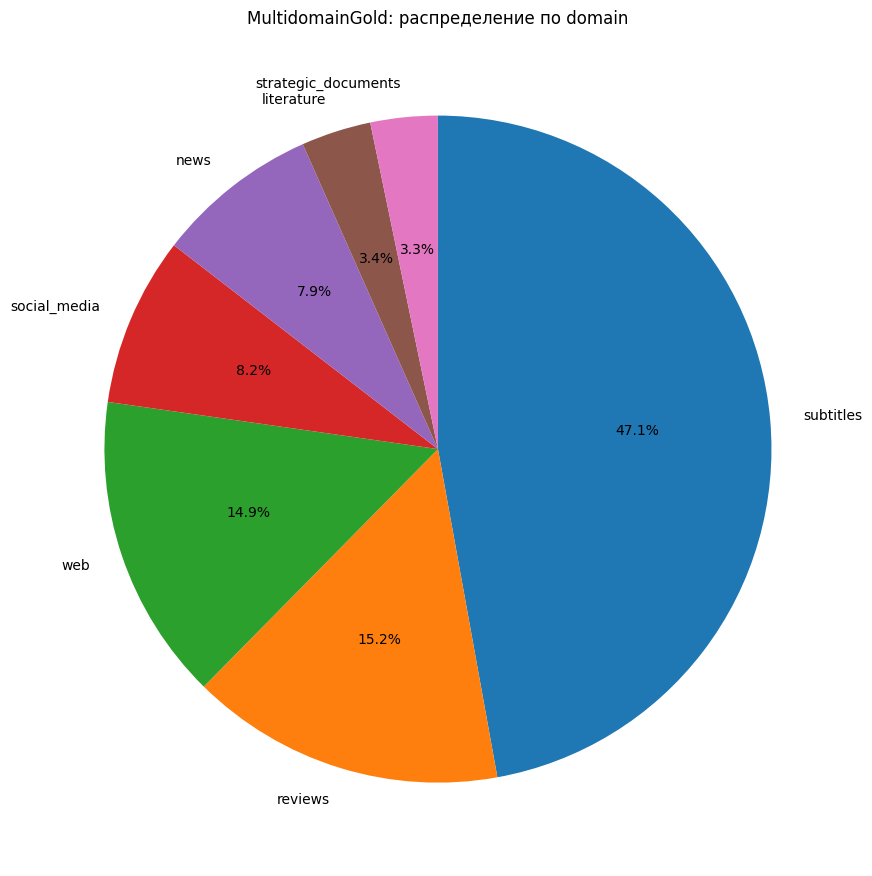

domain
subtitles              3620
reviews                1170
web                    1142
social_media            630
news                    606
literature              260
strategic_documents     250
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt

domain_counts = md_df["domain"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
ax.pie(
    domain_counts.values,
    labels=domain_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
ax.set_title("MultidomainGold: распределение по domain")
plt.tight_layout()
plt.show()

print(domain_counts)

In [6]:
import difflib


def char_diff_lines(source: str, correction: str) -> list[str]:
    """Позиции и символы, где source (с опечатками) и correction (оригинал) расходятся."""
    sm = difflib.SequenceMatcher(None, source, correction)
    lines = []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            continue
        if tag == "replace":
            for offset in range(max(i2 - i1, j2 - j1)):
                pos = i1 + offset
                sc = source[i1 + offset] if i1 + offset < i2 else None
                cc = correction[j1 + offset] if j1 + offset < j2 else None
                lines.append(
                    f"  [{pos}] source={sc!r} → correction={cc!r}"
                )
        elif tag == "delete":
            for pos in range(i1, i2):
                lines.append(f"  [{pos}] source={source[pos]!r} → correction=— (удалено)")
        elif tag == "insert":
            for j in range(j1, j2):
                lines.append(
                    f"  [{i1}] source=— → correction={correction[j]!r} (вставка)"
                )
    return lines


literature_df = md_df[md_df["domain"] == "literature"]
literature_with_errors = literature_df[
    literature_df["source"] != literature_df["correction"]
]
examples = literature_with_errors.head(10)

print(
    f"Домен literature: {len(literature_df)} примеров всего, "
    f"с ошибками: {len(literature_with_errors)}, показано {len(examples)}\n"
)

for i, row in enumerate(examples.itertuples(), start=1):
    print(f"--- Пример {i} (индекс строки в md_df: {row.Index}) ---")
    print(f"Оригинал:\n{row.correction}\n")
    print(f"С опечатками:\n{row.source}\n")
    diffs = char_diff_lines(row.source, row.correction)
    print("Различия (индекс в тексте с опечатками / source):")
    if diffs:
        print("\n".join(diffs))
    else:
        print("  (нет посимвольных различий)")
    print()

Домен literature: 260 примеров всего, с ошибками: 156, показано 10

--- Пример 1 (индекс строки в md_df: 3572) ---
Оригинал:
1812 г. А. Б. Куракин (1752–1818), будучи русским послом в Париже, после неудачных переговоров о выводе французских войск из Пруссии 29 апреля (11 мая) 1812 г. потребовал выдать паспорты ему и всему персоналу посольства для возвращения в Россию.

С опечатками:
1812 г. А. Б. Куракин (1752–1818), будучи русским послом в Париже, после неудачных переговоров о выводе французских войск из Пруссии 29 апреля (11 мая) 1812 г. потребовал выдать паспорты ему и всему персоналу посольства для возвращения в Россию.

Различия (индекс в тексте с опечатками / source):
  [4] source='\xa0' → correction=' '
  [156] source='\xa0' → correction=' '

--- Пример 2 (индекс строки в md_df: 3573) ---
Оригинал:
«А па-азвольте узнать, – заговорил он надменным голосом, – по какому праву вы здесь а-ахотитесь, мюлсвый сдарь?» Незнакомец говорил необыкновенно быстро, отрывочно и в нос.

С опечатк

In [15]:
!git clone https://github.com/ai-forever/sage.git

!pip install /content/sage

fatal: destination path 'sage' already exists and is not an empty directory.
Processing ./sage
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.5/22.5 MB 88.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 97.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 6.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 104.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
!pip install -e "/content/sage[errant]"

Obtaining file:///content/sage
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 79.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.1/506.1 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 79.7 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: blis
    Found existing installation: blis 1.3.3
    Uninstalling blis-1.3.3:
      Succe

In [42]:
!python -m spacy download ru_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.4/513.4 MB 1.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 104.8 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import sage.evaluation

/content/sage/sage/evaluation/ruerrant_wrapper/scorer.py:32: SyntaxWarning: invalid escape sequence '\]'
  infix_re = compile_infix_regex(nlp.Defaults.infixes[:-1] + ["\]\("])


In [40]:
import re
import sys
from pathlib import Path
from typing import Iterable

import difflib

# --- извлечение правок: source → target ---

_TOKEN_RE = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)


def tokenize_spellcheck(text: str) -> list[str]:
    """Токены для сравнения (слова и знаки препинания отдельно)."""
    return _TOKEN_RE.findall(text)


def extract_edits(source: str, target: str) -> dict[tuple[int, int], tuple[str, ...]]:
    """
    Правки при переходе source → target.
    Ключ: (start, end) — полуинтервал индексов токенов в source.
    Значение: кортеж токенов из target на этом участке.
    """
    src_tokens = tokenize_spellcheck(source)
    tgt_tokens = tokenize_spellcheck(target)
    edits: dict[tuple[int, int], tuple[str, ...]] = {}
    matcher = difflib.SequenceMatcher(None, src_tokens, tgt_tokens)
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "equal":
            continue
        replacement = tuple(tgt_tokens[j1:j2])
        if src_tokens[i1:i2] != list(replacement):
            edits[(i1, i2)] = replacement
    return edits


def extract_edits_corpus(
    sources: Iterable[str], targets: Iterable[str]
) -> dict[tuple[int, int, int], tuple[str, ...]]:
    """Все правки корпуса. Ключ: (номер_предложения, start, end)."""
    corpus_edits: dict[tuple[int, int, int], tuple[str, ...]] = {}
    for sent_id, (source, target) in enumerate(zip(sources, targets)):
        for (i, j), replacement in extract_edits(source, target).items():
            corpus_edits[(sent_id, i, j)] = replacement
    return corpus_edits


def spellcheck_precision_recall(
    sources: Iterable[str],
    corrections: Iterable[str],
    predictions: Iterable[str],
) -> dict[str, float]:
    """
    Precision / Recall для spellcheck (уровень правок).

    - sources: текст с опечатками (как ``source`` в MultidomainGold);
    - corrections: эталон (gold);
    - predictions: выход модели.

    TP — предсказанная правка совпала с эталонной на том же месте.
    Precision = TP / число предсказанных правок (лишние правки снижают метрику).
    Recall = TP / число эталонных правок (пропущенные ошибки снижают метрику).
    """
    sources = list(sources)
    corrections = list(corrections)
    predictions = list(predictions)
    if not (len(sources) == len(corrections) == len(predictions)):
        raise ValueError("sources, corrections и predictions должны быть одной длины")

    gold_edits = extract_edits_corpus(sources, corrections)
    pred_edits = extract_edits_corpus(sources, predictions)

    tp = sum(1 for key, pred_val in pred_edits.items() if gold_edits.get(key) == pred_val)

    n_pred = len(pred_edits)
    n_gold = len(gold_edits)
    precision = tp / n_pred if n_pred else 1.0
    recall = tp / n_gold if n_gold else 1.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0.0
    )

    return {
        "TP": tp,
        "num_gold_edits": n_gold,
        "num_pred_edits": n_pred,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1": round(f1 * 100, 2),
    }


def spellcheck_metrics_ruspelleval(
    sources: Iterable[str],
    corrections: Iterable[str],
    predictions: Iterable[str],
) -> dict[str, float]:
    """
    Метрики бенчмарка RUSpellEval (Sorokin et al.) через библиотеку sage в проекте.
    Требует: pip install numpy timeout-decorator tqdm и установленный пакет sage.
    """
    sage_root = Path("sage")
    if sage_root.is_dir() and str(sage_root.resolve().parent) not in sys.path:
        sys.path.insert(0, str(sage_root.resolve().parent))

    # from sage.evaluation.ruspelleval import evaluation

    # return evaluation(
    #     list(sources),
    #     list(corrections),
    #     list(predictions),
    # )

    from sage.evaluation import Scorer
    scorer = Scorer()
    return scorer.score(sources, corrections, predictions, metrics=["ruspelleval", "errant"])


# --- пример: идеальный корректор на literature (predictions = gold) ---
if "literature_with_errors" in dir():
    demo = spellcheck_metrics_ruspelleval(
        literature_with_errors["source"],
        literature_with_errors["correction"],
        literature_with_errors["correction"],
    )
    print("Демо (predictions = gold, домен literature):")
    print(demo)

OSError: [E050] Can't find model 'ru_core_news_lg'. It doesn't seem to be a Python package or a valid path to a data directory.

In [10]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("ai-forever/sage-fredt5-distilled-95m")
model = AutoModelForSeq2SeqLM.from_pretrained("ai-forever/sage-fredt5-distilled-95m")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/789 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/383M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [14]:
model.to("cuda")

sentence = "И не чсно прохожим в этот день непогожйи почему я веселый такйо"
inputs = tokenizer(sentence, max_length=None, padding="longest", truncation=False, return_tensors="pt")
outputs = model.generate(**inputs.to(model.device), max_length = inputs["input_ids"].size(1) * 1.5)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])

И не ясно прохожим в этот день непогожий, почему я весёлый такой?


In [ ]:
# literature_with_errors['source'][3572]

'1812\xa0г. А. Б. Куракин (1752–1818), будучи русским послом в Париже, после неудачных переговоров о выводе французских войск из Пруссии 29 апреля (11 мая) 1812\xa0г. потребовал выдать паспорты ему и всему персоналу посольства для возвращения в Россию.'

In [ ]:
# sources

NameError: name 'sources' is not defined

In [21]:
pred = []
for i, sentence in enumerate((literature_with_errors['source'])):
    # sentence = literature_with_errors['source'][i]
    print(i, sentence)
    inputs = tokenizer(sentence, max_length=None, padding="longest", truncation=False, return_tensors="pt")
    outputs = model.generate(**inputs.to(model.device), max_length = inputs["input_ids"].size(1) * 1.5)
    pred.append(tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])
len(pred)

0 1812 г. А. Б. Куракин (1752–1818), будучи русским послом в Париже, после неудачных переговоров о выводе французских войск из Пруссии 29 апреля (11 мая) 1812 г. потребовал выдать паспорты ему и всему персоналу посольства для возвращения в Россию.
1 «А па-азвольте узнать, – заговорил он надменным голосом, – по какому праву вы здесь а-ахотитесь, мюлсвый сдарь?» Незнакомец говорил необыкновенно быстро, отрывочно и в нос.
2 А между тем для художника слова эти не имеют никакого смысла и даже не затрогивают самого события.
3 Без сомнения, он понимал, что, отрицая нравственную ответственность личности, он тем самым отрицает и свободу ее; но он верил всем существом своим (гораздо слепее Герцена, который, кажется, под конец усумнился), что социализм не только не разрушает свободу личности, а, напротив, восстановляет ее в неслыханном величии, но на новых и уже адамантовых основаниях.
4 Да и в самом деле, вы посудите: безденежье меня приковывало к ненавистной мне деревне; ни хозяйство, ни служба

156

In [24]:
demo = spellcheck_metrics_ruspelleval(
        literature_with_errors["source"],
        literature_with_errors["correction"],
        pred,
    )
print("Демо (predictions = gold, домен literature):")
print(demo)

demo_ai = spellcheck_precision_recall(
    literature_with_errors["source"],
    literature_with_errors["correction"],
    pred,
)
print("Демо ручное (predictions = gold, домен literature):")
print(demo_ai)

Calculating words metric:   0%|          | 0/156 [00:00<?, ?it/s]

Демо (predictions = gold, домен literature):
{'Precision': 30.26, 'Recall': 74.19, 'F1': 42.99}
Демо ручное (predictions = gold, домен literature):
{'TP': 130, 'num_gold_edits': 225, 'num_pred_edits': 477, 'precision': 0.27253668763102723, 'recall': 0.5777777777777777, 'f1': 0.3703703703703703, 'Precision': 27.25, 'Recall': 57.78, 'F1': 37.04}


In [ ]:
pred_BW = []
for i, sentence in enumerate((sources)):
    # sentence = literature_with_errors['source'][i]
    # if sentence is None:
        
    print(i, sentence)
    inputs = tokenizer(sentence, max_length=None, padding="longest", truncation=False, return_tensors="pt")
    outputs = model.generate(**inputs.to(model.device), max_length = inputs["input_ids"].size(1) * 1.5)
    pred_BW.append(tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])
len(pred_BW)

0 Златые времена! О кроткин законы! народу своему прощант миллионы;
1 Воротился старик ко старухе ,У старухи новое корвто.
2 - Вы, кажется, решительно предпочитпетн камеристок.
3 Сказкв о попе и о работнике его Балде автлр Александр Сергеевич Пушкин (1799-1837) СКАЗКА О ПОПЕ И О РАБОТНИКЕ ЕГО БПЛДН Жил был поп, Толоконныц лоб 
4 Герианн трепетал, как тигр, лжидпч назначенного вреиент.
5 староста сначала было удивился;
6 С нею бвл коротко знаком человек очень замесатпльныц.
7 Вскоре на одной сторонн улицы из-за угольного дома покпзплся солодоц лфицер.
8 Астроном весь своц век в бесплодном бфл труде, запктан циклами, пока восстал Коперник, Презритнль зависти и варварству соперник: В сеединн всех планет он солнце положио, Сугубое земли двиденин открыл.
9 Он нарочно для нее прорезал отверстие в своей двери, и она как будто чувствовала, что только в Герасивомов каморке она была плная хозяйка, и потому , войдя в нее , точтас с довольным видом вскакивала на кровать
10 слева, другая в кордиор.

156

In [34]:
pred_BW

['Златые времена! О кроткие законы! Народу своему прощают миллионы.',
 'Воротился старик ко старухе. У старухи новое корыто.',
 '- Вы, кажется, решительно предпочитаете камеристок.',
 'Сказка о попе и о работнике его Балде, автор Александр Сергеевич Пушкин (1799-1837) - сказка о попе и о работнике его БПЛАДН. Жил был поп, Толоконный лоб. ',
 'Герианн трепетал, как тигр, ожидая назначенного времени.',
 'Староста сначала был удивился.',
 'С нею был коротко знаком человек очень замечательный.',
 'Вскоре на одной стороне улицы из-за угольного дома показался молодой офицер.',
 'Астроном весь свой век в бесплодном был труде, запутан циклами, пока восстал Коперник, Презритель зависти и варварству соперник: в середине всех планет он солнце положил, Сугубое земли Двиденин открыл.',
 'Он нарочно для неё прорезал отверстие в своей двери, и она как будто чувствовала, что только в Герасимовом каморке она была плотная хозяйка, и потому, войдя в неё, тотчас с довольным видом вскакивала на кровать.',


In [43]:
demo = spellcheck_metrics_ruspelleval(
        sources,
        corrections,
        pred_BW,
    )
print("Демо (predictions = BW Spellcheck):")
print(demo)

Calculating words metric:   0%|          | 0/579 [00:00<?, ?it/s]

/content/sage/sage/evaluation/ruspelleval.py:359: UserWarning: Skipping 30 line, because operation timed out...
  warnings.warn("Skipping {} line, because operation timed out...".format(num), UserWarning)


Calculating errant metric:   0%|          | 0/579 [00:00<?, ?it/s]

Демо (predictions = BW Spellcheck):
{'Precision': 69.38, 'Recall': 60.58, 'F1': 64.68, 'SPELL_Precision': 66.36, 'SPELL_Recall': 53.79, 'SPELL_F1': 59.41, 'CASE_Precision': 18.34, 'CASE_Recall': 51.85, 'CASE_F1': 27.1, 'PUNCT_Precision': 26.09, 'PUNCT_Recall': 53.85, 'PUNCT_F1': 35.15, 'YO_Precision': 3.33, 'YO_Recall': 62.5, 'YO_F1': 6.33}


In [44]:
# Fine-tune Qwen/Qwen3.5-0.8B для spellcheck (LoRA + SFT)
# Перед запуском (Colab/GPU):
# !pip install -U "transformers>=4.57" peft trl bitsandbytes accelerate datasets

import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig, TrainingArguments
from trl import SFTTrainer

MODEL_ID = "Qwen/Qwen3.5-0.8B"
OUTPUT_DIR = "./qwen35_0.8b_spellcheck_lora"
SYSTEM_PROMPT = (
    "Исправь орфографические ошибки в русском тексте. "
    "Верни только исправленный текст без пояснений."
)


def build_spellcheck_dataset(source_texts, target_texts):
    rows = []
    for src, tgt in zip(source_texts, target_texts):
        if not src or not tgt or src.strip() == tgt.strip():
            continue
        rows.append(
            {
                "messages": [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": src.strip()},
                    {"role": "assistant", "content": tgt.strip()},
                ]
            }
        )
    return Dataset.from_list(rows)


# sources = текст с опечатками, corrections = эталон (см. ячейку загрузки BW)
if "sources" in dir() and "corrections" in dir():
    train_sources, train_targets = sources, corrections
# elif "md_sources" in dir() and "md_corrections" in dir():
#     train_sources, train_targets = md_sources, md_corrections
else:
    raise RuntimeError("Сначала выполните ячейку загрузки датасета.")

raw_dataset = build_spellcheck_dataset(train_sources, train_targets)
raw_dataset = raw_dataset.train_test_split(test_size=0.5, seed=42)
print(f"Train: {len(raw_dataset['train'])}, eval: {len(raw_dataset['test'])}")

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer = processor.tokenizer

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_4bit = torch.cuda.is_available()

bnb_config = None
if use_4bit:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
        bnb_4bit_use_double_quant=True,
    )

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16 if use_bf16 else torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

if use_4bit:
    model = prepare_model_for_kbit_training(model)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


def formatting_func(example):
    return processor.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
        enable_thinking=False,
    )


training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_steps=100,
    save_total_limit=2,
    bf16=use_bf16,
    fp16=not use_bf16 and torch.cuda.is_available(),
    gradient_checkpointing=True,
    report_to="none",
    optim="adamw_8bit" if use_4bit else "adamw_torch",
    max_grad_norm=1.0,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=raw_dataset["train"],
    eval_dataset=raw_dataset["test"],
    processing_class=tokenizer,
    formatting_func=formatting_func,
    max_seq_length=512,
    packing=False,
)

trainer.train()
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f"LoRA adapter saved to {OUTPUT_DIR}")


RuntimeError: Failed to import transformers.models.auto.processing_auto because of the following error (look up to see its traceback):
operator torchvision::nms does not exist